# LAB 2: Prognosis and survival functions

In this lab, we will analyze observations from different ovarian cancer patients and we will create different survival functions employing univariate (Kaplan-Meier estimate) and multivariate (CPH and Extra Survival Trees) analysis.

Remember to copy this notebook into your own drive and your JHED ID as suffix (It's the part before the @ symbol in your email, not your Hopkins ID in the SIS):


*   eg: Lab2_Prognosis_myjhedID

Please always remember to use the MLMA coding rubric.

In [40]:
# Install the package you need for this lab
# You may need to install them every time you restart the runtime
!pip install lifelines
!pip install xlrd
!pip install scikit-survival

In [41]:
# Feel free to add more libraries if you need them
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pandas.api.types import is_numeric_dtype


from sksurv.ensemble import ExtraSurvivalTrees
from sksurv.preprocessing import OneHotEncoder
import xlrd
import zipfile

**DATA**

The data that we are going to use in this lab is a subset of the data described in the paper ["Gene Expression Profile for Predicting Survival in Advanced-Stage Serous Ovarian Cancer Across Two
Independent Datasets"](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0009615). According to the authors:

>One hundred ten Japanese patients who were diagnosed with advanced-stage serous ovarian cancer between July 1997 and June 2008 were included in this study. Fresh-frozen samples were obtained from primary tumor tissues during primary debulking surgery prior to chemotherapy. [...] frozen tissues containing more than 80% of tumor cells upon histological evaluation were used for RNA extraction. [...] Optimal debulking surgery was defined as ≤ 1cm of gross residual disease. [...] Overall survival time was calculated as the interval from primary surgery to the death due to ovarian cancer.

For our purposes, we are going to consider time-to-death, debulking optimality, and five biomarker genes associated with ovarian cancer survival (CXCL12, NCOA3, PDPN, TEAD1, YWHAB).

In [42]:
# Load the data (adjust path if necessary)
df=pd.read_csv('./data.csv')

In [43]:
# Visualize the data and obtain statistics (number of observations and predictor variables)
print('Number of observations: ', len(df))
print('Number of predictor variables: ', len(df.columns)-1)
df.head()

Number of observations:  84
Number of predictor variables:  6


,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3
0,GSM432220,1650,0,0,-0.526989,1.305942,0.144564
1,GSM432221,30,1,1,-0.180496,1.286216,-0.455337
2,GSM432222,720,0,1,0.747367,-1.369031,0.626061
3,GSM432223,780,0,1,-0.425558,1.613270,0.458312
4,GSM432224,990,1,1,-0.476626,0.611514,-0.218782


## Task 1. Check your data (3 POINTS)
---
Please check the debulking optimality and CXCL12 gene expression distributions of the dataset

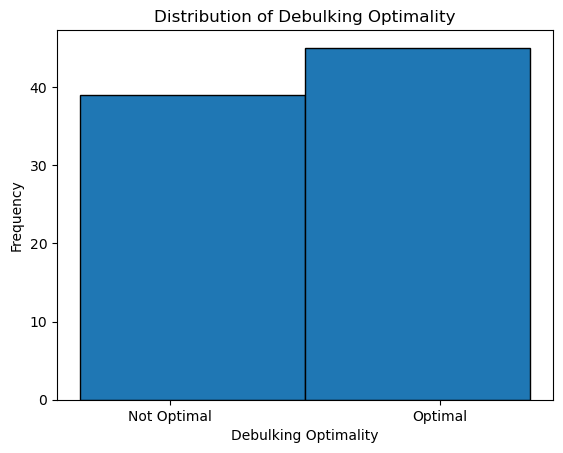

Number of patients expressing NCOA3 gene: 40


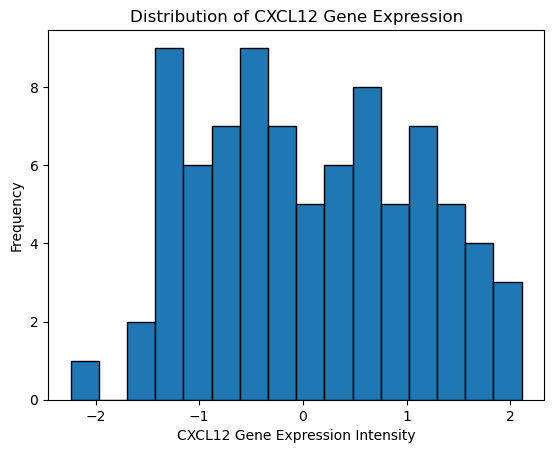

In [44]:
# Please plot a histogram of the debulking optimality distribution:
# debulk:0 - not optimal
# debulk:1 - optimal


# YOUR CODE GOES HERE

plt.hist(df['debulk'], bins=2, edgecolor='black')
plt.xlabel('Debulking Optimality')
plt.ylabel('Frequency')
plt.title('Distribution of Debulking Optimality')
plt.xticks([0.2, 0.8], ['Not Optimal', 'Optimal'])
plt.show()
# and answer a question briefly：how many patients in this dataset expressed the NCOA3 gene (NCOA3>0)?
ncoa3_patients = df[df['NCOA3'] > 0]
print(f"Number of patients expressing NCOA3 gene: {len(ncoa3_patients)}")

# Please plot a histogram of the CXCL12 gene expression distribution:
# The numeric values represent a patient's gene expression intensity, with high values indicating high levels of expression.

# YOUR CODE GOES HERE
bins = int(len(np.unique(df['CXCL12'])) / 5)  # Calculate the number of bins based on unique values
plt.hist(df['CXCL12'], bins=bins, edgecolor='black')
plt.xlabel('CXCL12 Gene Expression Intensity')
plt.ylabel('Frequency')
plt.title('Distribution of CXCL12 Gene Expression')
plt.show()

In [45]:
display(df["CXCL12"].describe())

display(df["CXCL12"].value_counts()
        .sort_values()
        .reset_index()
        .rename(columns={"index": "CXCL12", "CXCL12": "Frequency"}))

print(f"Skewness of CXCL12 gene expression: {df['CXCL12'].skew()}")

count    84.000000
mean      0.088129
std       1.028795
min      -2.239108
25%      -0.707846
50%       0.014794
75%       0.908764
max       2.107385
Name: CXCL12, dtype: float64

,Frequency,count
0,1.305942,1
1,1.286216,1
2,-1.369031,1
3,1.613270,1
4,0.611514,1
...,...,...
79,0.897661,1
80,-0.126275,1
81,0.666737,1
82,-0.511819,1


Skewness of CXCL12 gene expression: 0.0856443002632512


## Task 2 (2 POINT)
---
Do you think the dataset we are using is balanced in terms of CXCL12 gene expression? Why or why not?

Answer:

No the data set is not perfectly balanced in terms of raw counts but it seems to be balanced in a sense that it looks normalized. The mean is very close to zero and the standard deviation is 1. And the skewness is between -0.5 and 0.5.

# 1. Prognostic Model

Different from survival models, prognostic models try to answer questions referred to fixed period or related to a certain event.

## TASK 3 (4 POINTS)
---
The maximum follow-up time for patients in was 2430 days. Answer the following quesitons briefly (without repeating any answers).

In [46]:
display(df[df.ID == "GSM432223"])

,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3
3,GSM432223,780,0,1,-0.425558,1.61327,0.458312


1. Patient GSM432223 is listed as having time = 60 days and death = 0. What is a potential conclusion you can draw about their outcome?

Answer:

This means that patient GSM432223 was recorded as surviving until day 60, after which no further data was collected. Perhaps the patient discontinued participation in the study. No death was officially recorded. All we know is that, during their time in the study, the patient survived for 60 days.

In [47]:
display(df[df.ID == "GSM432229"])

,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3
8,GSM432229,1710,1,1,-0.262738,0.373057,-1.372724


2. Patient GSM432229 is listed as having time = 1710 days and death = 1. What is a potential conclusion you can draw about their outcome?

Answer:

Patient GSM432229 survived for 1,710 days and then unfortunately died. In this record, we know that the patient survived for 1,710 days before dying.



3. Patient GSM432307 is listed as having time = 2430 days and death = 0. What is a potential conclusion you can draw about their outcome?

In [48]:
display(df[df.ID == "GSM432307"])

print(max(df.time))

,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3
69,GSM432307,2430,0,1,-0.809211,1.720215,-0.270117


2430


Answer:

Here what we know is the patient survived in the whole time of the research participation because they have the maximum time recorded in the dataset.

4. Assuming that your conclusions are all true, which one of the above patients is considered censored?

Answer:

Patient GSM432223 is considered censored because their survival was not recorded for the entire duration of the study, nor was their death recorded. All we know from the data is that the patient survived for 60 days and that their participation in the study was subsequently discontinued.

## TASK 4 (2 POINTS)
---
To build a prognostic model (for instance, a model that predicts if someone will die at or before 90 days after surgical intervention for ovarian cancer), we should always delete all or part of the censored data. Briefly expain why this is necessary.

Answer:

This is because we would have NaN values in our dataset. The dependent variable in our dataset—the outcome we are trying to predict (in this case, a person’s chance of survival)—should have a definitive answer of “yes” or “no.” However, for patients who discontinued their participation in the study, we do not know whether they ultimately survived or not.

# 2. Univariate analysis: Univariate survival functions and cumulative hazard

## TASK 5 (5 POINTS)

What is the probablity of a patient being alive after 1500 days? i.e. Calculate $P_s(1500)$

In [49]:
# YOUR CODE GOES HERE
# 
unique_days = sorted(df["time"].unique())
print(f"Number of unique time points: {len(unique_days)}")

probability_of_survival = 1.0
n_at_risk = len(df)

for days in unique_days:
    if (days >= 1500):
        break
    
    n_died = len(df[(df['time'] == days) & (df['death'] == 1)])
    n_censored = len(df[(df['time'] == days) & (df['death'] == 0)])
    
    if n_died > 0:
            probability_of_survival *= (1 - (n_died / n_at_risk))
        
    n_at_risk -= (n_died + n_censored)
    
print(f"Estimated probability of survival at 1500 days: {probability_of_survival:.4f}")

    

Number of unique time points: 46
Estimated probability of survival at 1500 days: 0.5514


## TASK 6 (10 POINTS)
---

Calculate and plot the survival function employing the Kaplan-Meier estimate  

In [50]:
# Calculate and plot the survival function employing the Kaplan-Meier estimate
def calculate_survival_KM(df, TimeColumn, EventColumn, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR):
  """
Generates a dataframe containing the survival function (time vs probability of survival)
employing the Kaplan-Meier estimate.
Inputs:
      df: input dataframe
      TimeColumn: name of the colum containing the event time
      EventColumn: name of the column indicating if the event happened HAPPEN_INDICATOR or not NOT_HAPPEN_INDICATOR
      EVENT_HAPPEN_INDICATOR: the indicator status when event happens, like 1 for death
      EVENT_NOT_HAPPEN_INDICATOR: the indicator status when event does not happen, like 0 for alive
Outputs:
      dfSurv: dataframe containing the time and probability of survival
  """

  # YOUR CODE GOES HERE
  unique_times = sorted(df[TimeColumn].unique())
  n_at_risk = len(df)
  probability_of_survival = 1.0
  survival_data = []

  for time in unique_times:
      n_died = len(df[(df[TimeColumn] == time) & (df[EventColumn] == EVENT_HAPPEN_INDICATOR)])
      n_censored = len(df[(df[TimeColumn] == time) & (df[EventColumn] == EVENT_NOT_HAPPEN_INDICATOR)])
      
      if n_died > 0:
          probability_of_survival *= (1 - (n_died / n_at_risk))
      
      survival_data.append({'time': time, 'survival_probability': probability_of_survival})
      
      n_at_risk -= (n_died + n_censored)

  dfSurv = pd.DataFrame(survival_data)
  return dfSurv


def plot_survival(df, TimeColumn, EventColumn, Name, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR):
  """
  This function plots the survival function of the whole df. This function calls
  calculate_survival_KM.
  Inputs:
      df: input dataframe
      TimeColumn: name of the colum containing the event time
      EventColumn: name of the column indicating if the event happened (1) or not (0)
      Name: legend to display, associated to the survival function
      EVENT_HAPPEN_INDICATOR: the indicator status when event happens, like 1 for death
      EVENT_NOT_HAPPEN_INDICATOR: the indicator status when event does not happen, like 0 for alive

  """
  # YOUR CODE GOES HERE
  dfSurv = calculate_survival_KM(df, TimeColumn, EventColumn, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR)
  plt.plot(dfSurv[TimeColumn], dfSurv['survival_probability'], label=Name)
  plt.xlabel('Time')
  plt.ylabel('Survival Probability')
  plt.legend()

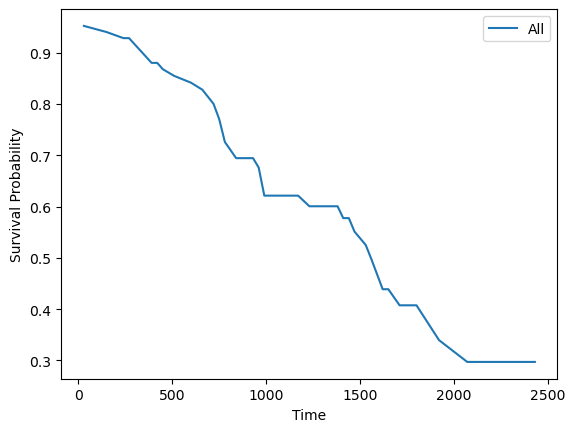

In [51]:
# Plot the survival function obtained with the entire dataframe
TimeColumn='time'
EventColumn='death'
plot_survival(df, TimeColumn, EventColumn, 'All', 1, 0)

## TASK 7 (10 POINTS)
---
Code a function that displays the survival function of two categories of a certain predictor (e.g. ANKRD27 expression > 0 vs. ANKRD27 expression ≤ 0) in the same plot.

In [52]:
# function to print two categories
def plot_survival_twocat(df, predictor, cat1, cat0,cat1_name, cat0_name ):
      """
      Displays the survival function of two categories of a certain predictor
      (eg. optimal vs. nonoptimal debulking, NCOA3 expression > 1 vs. NCOA3 expression ≤ 1) in the same plot. This function
      only considers binary categories: 0 and 1.
      Inputs:
            df: input dataframe
            predictor: column containing the predictor variable that we want to study
            cat1: Label of the category associated to one category (eg. '0')
            cat0: Label of the category associated to the other category (eg. '1')
            cat1_name: Name for cat1's label (eg. 'debulked')
            cat0_name: Name for cat0's label (eg. 'not_debulked')
      """
      
      # NOTE: Using greater and less than or equal to operators allows us to consider categories that are not strictly binary 
      df1 = df[df[predictor] >= cat1]
      df0 = df[df[predictor] <= cat0]
      
      plot_survival(df1, 'time', "death", cat1_name, 1, 0)
      plot_survival(df0, 'time', "death", cat0_name, 1, 0)
  # YOUR CODE GOES HERE

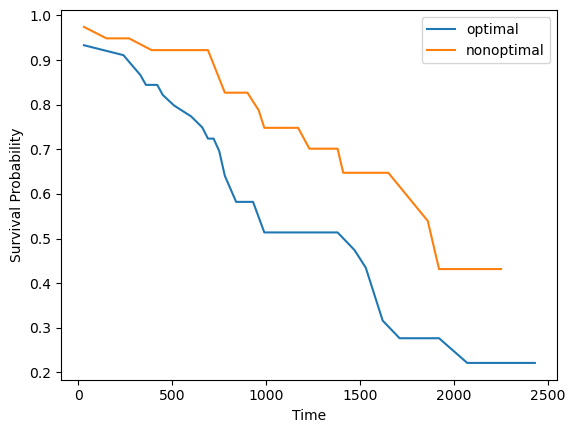

In [53]:
# Plot survival for tumor size ≥ 1 cm vs. tumor size < 1
predictor = 'debulk'
cat1 = 1
cat0 = 0
cat1_name = 'optimal'
cat0_name = 'nonoptimal'
plot_survival_twocat(df, predictor, cat1, cat0,cat1_name,cat0_name )

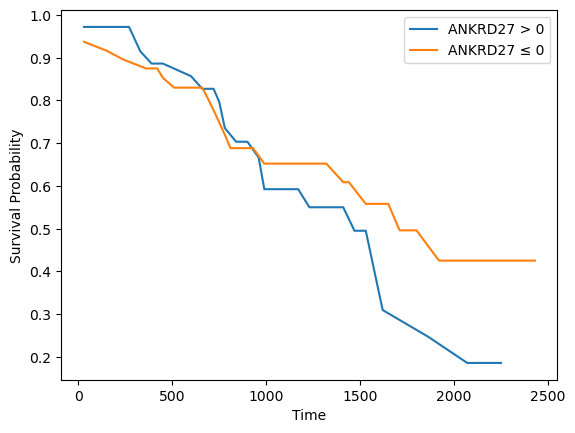

In [54]:
# Plot survival for ANKRD27 expression > 0 vs. ANKRD27 expression ≤ 0

# YOUR CODE GOES HERE
plot_survival_twocat(df, 'ANKRD27', 0, 0, 'ANKRD27 > 0', 'ANKRD27 ≤ 0')

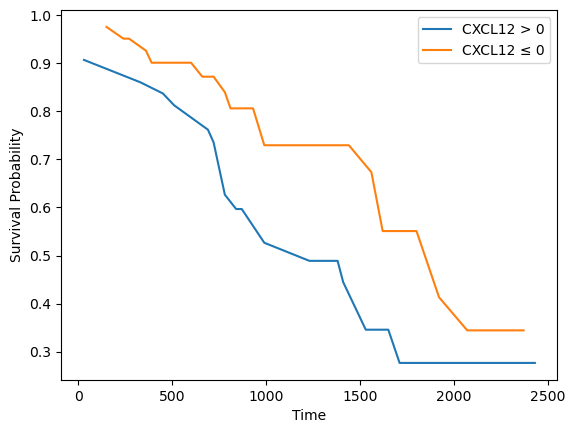

In [55]:
# Plot survival for CXCL12 expression > 0 vs. CXCL12 expression ≤ 0

# YOUR CODE GOES HERE
plot_survival_twocat(df, 'CXCL12', 0, 0, 'CXCL12 > 0', 'CXCL12 ≤ 0')

Which predictor above influences the survival probability in the first 500 days the least?

Answer:

I would say ANKRD27 because, based on the plot, it appears to have the least effect on survival probability. We can see that for ANKRD27, the survival function remains constant for the first few hundred days.

## TASK 8 (10 POINTS)
---
Plot the cumulative Hazard using the Nelson-Aalen estimator

In [56]:
# Plot the cumulative Hazard using the Nelson-Aalen estimator
def cumulative_hazard_NA(df, TimeColumn, EventColumn, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR):
  """
  Generates a dataframe containing the cumulative hazard  (H(t)) employing the
  Nelson-Aalen estimator.
  Inputs:
        df: input dataframe
        TimeColumn: name of the colum containing the event time
        EventColumn: name of the column indicating if the event happened or not
        EVENT_HAPPEN_INDICATOR: the indicator status when event happens, like 1 for death
        EVENT_NOT_HAPPEN_INDICATOR: the indicator status when event does not happen, like 0 for being alive
  Outputs:
        dfH: dataframe containing the time and Cumulative Hazard (H(t))
  """

  unique_times = sorted(df[TimeColumn].unique())
  hazard_data = []
  n_at_risk = len(df)
  cumulative_hazard = 0.0
  
  for time in unique_times:
    n_died = len(df[(df[TimeColumn] == time) & (df[EventColumn] == EVENT_HAPPEN_INDICATOR)])
    n_censored = len(df[(df[TimeColumn] == time) & (df[EventColumn] == EVENT_NOT_HAPPEN_INDICATOR)])
    
    # Calculate the hazard increment for this time point
    if n_died > 0:
        cumulative_hazard += n_died / n_at_risk
    
    # Store the cumulative hazard for this time point
    hazard_data.append({'time': time, 'cumulative_hazard': cumulative_hazard})
    
    # Update the number at risk for the next time point
    n_at_risk -= (n_died + n_censored)

      # First reuse the code to calculate the survival function then just 

  dfH = pd.DataFrame(hazard_data)
  return dfH

def plot_cumH(df, TimeColumn, EventColumn, Name,EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR):
  """
  This function plots the cumulative hazard of the whole df. This function calls
  calculate_hazard_NA.
  Inputs:
      df: input dataframe
      TimeColumn: name of the colum containing the event time
      EventColumn: name of the column indicating if the event happened (1) or not (0)
      Name: legend to display, associated to the CH
      EVENT_HAPPEN_INDICATOR: the indicator status when event happens, like 1 for death
      EVENT_NOT_HAPPEN_INDICATOR: the indicator status when event does not happen, like 0 for being alive
  """
  dfH = cumulative_hazard_NA(df, TimeColumn, EventColumn, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR)
  plt.plot(dfH[TimeColumn], dfH['cumulative_hazard'], label=Name)
  plt.xlabel('Time')
  plt.ylabel('Cumulative Hazard')
  plt.legend()

  # YOUR CODE GOES HERE

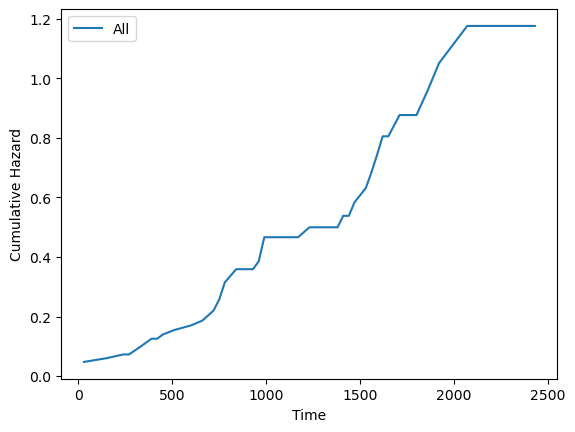

In [57]:
# Plot the cumulative hazard of df
TimeColumn='time'
EventColumn='death'
plot_cumH(df, TimeColumn, EventColumn, 'All', 1, 0)

# 2. Multivariate analysis
**Cox Proportional Hazards**

Now, we are going to employ multivariate analysis using CPH to determine the survival funtions and the hazard ratio of different patients.
We will employ [lifelines](https://lifelines.readthedocs.io/en/latest/index.html), a python survival analysis library. The relevant packages have been imported for you at the beginning.

## TASK 9 (5 POINTS)
---
Divide the dataframe into 80% training and 20% testing subsets and normalize the data.

In [58]:
#Divide the data into dfTrain 80% and dfTest 20%:
#And normalize the data
# YOUR CODE GOES HERE

# Separate features from targets
features = ['debulk', 'ANKRD27', 'CXCL12', 'NCOA3']
targets = ['time', 'death']

# Normalize the features
scaler = StandardScaler()
df_scaled_features = scaler.fit_transform(df.drop(columns=['ID', 'time', 'death']))
df_scaled_features = pd.DataFrame(df_scaled_features, columns=features)

df_final = pd.concat([df_scaled_features, df[targets]], axis=1)

dfTrain, dfTest = train_test_split(df_final, test_size=0.2, random_state=42)





## TASK 10 (5 POINTS)
---
Calculate and print the Cox proportional hazards coefficients of the training subset (dfTrain). As the data was normalized, the coefficients will provide information about the magnitude of the effect of each predictor variables. You can use CoxPHFitter from lifelines to do that.

In [59]:
# Calculate and print the Cox proportional hazards coefficients

cph = CoxPHFitter()
cph.fit(dfTrain, duration_col='time', event_col='death')
print("Cox Proportional Hazards Coefficients:")
print(cph.summary)

# YOUR CODE GOES HERE

Cox Proportional Hazards Coefficients:
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
debulk     0.462967   1.588780  0.231972        0.008311        0.917623   
ANKRD27   -0.015107   0.985006  0.172250       -0.352712        0.322498   
CXCL12     0.133725   1.143079  0.202762       -0.263680        0.531131   
NCOA3      0.581481   1.788686  0.209730        0.170418        0.992544   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
debulk                1.008345             2.503332     0.0  1.995790   
ANKRD27               0.702780             1.380572     0.0 -0.087705   
CXCL12                0.768219             1.700854     0.0  0.659519   
NCOA3                 1.185800             2.698090     0.0  2.772523   

                  p  -log2(p)  
covariate                      
d

<lifelines.CoxPHFitter: fitted with 67 total observations, 38 right-censored observations>
             duration col = 'time'
                event col = 'death'
      baseline estimation = breslow
   number of observations = 67
number of events observed = 29
   partial log-likelihood = -95.07
         time fit was run = 2026-02-15 03:06:34 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
debulk     0.46      1.59      0.23            0.01            0.92                1.01                2.50
ANKRD27   -0.02      0.99      0.17           -0.35            0.32                0.70                1.38
CXCL12     0.13      1.14      0.20           -0.26            0.53                0.77                1.70
NCOA3      0.58      1.79      0.21            0.17            0.99                1.19                2.70

           cmp to     z    p  -log2(p)
covariate                             
debulk       0.00  2.00 0.05      4.44
ANKRD27      0.00 -0.09 0.93      0.10
CXCL12       0.00  0.66 0.51      0.97
NCOA3        0.00  2.77 0.01      7.49
---
Concordance = 0.70
Partial AIC = 198.15
log-likelihood ratio test = 12.45 on 4 df
-log2(p) of ll-ratio test = 6.13

<Axes: xlabel='log(HR) (95% CI)'>

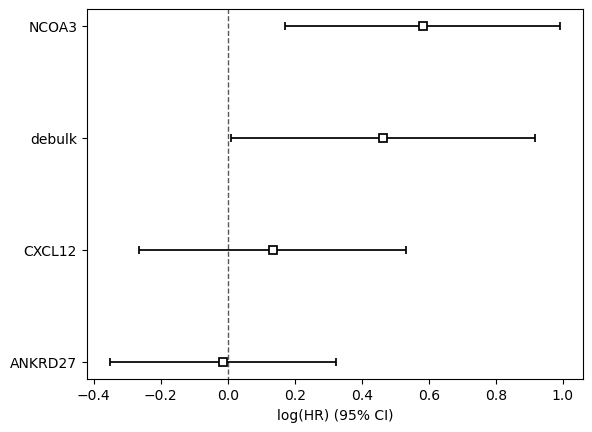

In [60]:
cph.print_summary()
cph.plot()

In [61]:
cph.params_.values

array([ 0.46296668, -0.01510719,  0.13372516,  0.58148102])

## TASK 11 (5 POINTS)
---
Plot the survival function of the three first participants in the test subset.

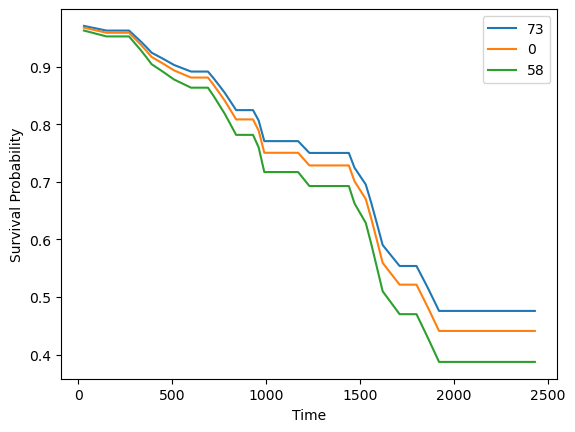

In [62]:
import matplotlib.pyplot as plt

participant1 = 0
participant2 = 1
participant3 = 2

fig, ax = plt.subplots()

cph.predict_survival_function(
    dfTest.iloc[[participant1]]
).plot(ax=ax, label=f'Participant {participant1}')

cph.predict_survival_function(
    dfTest.iloc[[participant2]]
).plot(ax=ax, label=f'Participant {participant2}')

cph.predict_survival_function(
    dfTest.iloc[[participant3]]
).plot(ax=ax, label=f'Participant {participant3}')

ax.set_xlabel('Time')
ax.set_ylabel('Survival Probability')
ax.legend()

plt.show()


What is the most important property of CPH that you observe in the plot in terms of the shape of the three lines? (You can say more but we are looking for one key word)



Answer:

From CPH we can see that the 3 plots are proportional They all have the same shape and shifts, its just one of the plot is a constant multiple of the others.

## TASK 12 (10 POINTS)
---
Create a function that calculates the hazard ratio between two patients. This tells us which one of the two patients is at a higher risk.

In [63]:
# Create a function that calculates the hazard ratio between two patients.
# This will tell us which patient is at a higher risk.
def hazard_ratio(df, participant1, participant2, cph):
    '''
    Calculates the hazard ratio of participant1 vs participant 2 using
    the coefficients of the CPH model.

    Inputs:
        df: dataframe containing all the participants of the study subset
        participant1: index of the first participant in the df.
        participant2: index of the second participant in the df.
        cph: CPH model obtained with lifelines
    Outputs:
        HR: hazard ratio of participant 1 vs participant 2
    '''
    
    
    # Calculate hazard ratio
    partial_hazard_1 = cph.predict_partial_hazard(df.iloc[[participant1]]).values[0]
    partial_hazard_2 = cph.predict_partial_hazard(df.iloc[[participant2]]).values[0]
    
    print(f"Partial hazard for participant {participant1}: {partial_hazard_1}")
    print(f"Partial hazard for participant {participant2}: {partial_hazard_2}")

    HR = partial_hazard_1 / partial_hazard_2 if partial_hazard_2!= 0 else float('inf')

    # YOUR CODE GOES HERE

    return HR

In [64]:
print('Participant 1 vs participant 2 Hazard Ratio: ' + str(hazard_ratio(dfTest, 5, 10, cph)))

Partial hazard for participant 5: 1.0617130802067396
Partial hazard for participant 10: 2.7122111883182534
Participant 1 vs participant 2 Hazard Ratio: 0.39145664053729917


## TASK 13 (15 POINTS)
---
Create a function to calculate the concordance index of the CPH model you just trained, using the test data.

In [65]:
# concordance index function
def c_index_mlma(df, TimeColumn, EventColumn, cph):
    '''
    Computes the C-Index employing the testing data and trained models.

   Inputs:
      df: input dataframe
      TimeColumn: name of the colum containing the event time
      EventColumn: name of the column indicating if the event happened (1) or not (0)
      cph: CPH model obtained with lifelines
  Outputs:
      CI: Concordance Index
    '''


    """
     y_true (array): array of true event times
        scores (array): model risk scores
        event (array): indicator, 1 if event occurred at that index, 0 for censorship
    """

    # YOUR CODE GOES HERE
    predicted_risk = cph.predict_partial_hazard(df).values.flatten()
    y_true = df[TimeColumn].values
    event = df[EventColumn].values
    
    CI = concordance_index(y_true, -predicted_risk, event)

    return CI

In [66]:
dfTest.head()

,debulk,ANKRD27,CXCL12,NCOA3,time,death
73,-1.074172,0.213474,0.461545,0.123909,780,1
0,-1.074172,-0.457245,1.190836,0.105860,1650,0
58,-1.074172,-1.171436,0.752242,0.441647,750,1
22,-1.074172,-1.320352,0.853126,-0.922012,2220,0
12,0.930949,0.264830,-0.819317,0.863254,2070,1


In [67]:
# Concordance Index of the training data
TimeColumn='time'
EventColumn='death'
CI=c_index_mlma(dfTrain, TimeColumn, EventColumn, cph)
print(CI)

0.6974865350089766


In [68]:
# Your output above be similar to the CI calculated by the lifelines library (+/- 0.015)
print(cph.concordance_index_)

0.6974865350089766


In [69]:
# Concordance Index of the testing data

# YOUR CODE GOES HERE
TimeColumn='time'
EventColumn='death'
CI=c_index_mlma(dfTest, TimeColumn, EventColumn, cph)
print(CI)


0.684931506849315


# Survival Trees

Now, we are going to use a different type of multivariate analysis to calculate survival functions: ExtraSurvivalTrees. To perform this type of analysis, we will employ the [scikit-survival library](https://scikit-survival.readthedocs.io/en/stable/index.html).


## TASK 14 (5 POINTS)
---
Train a estimator using the training subset .

In [70]:
display(dfTest.head())

display(df)

,debulk,ANKRD27,CXCL12,NCOA3,time,death
73,-1.074172,0.213474,0.461545,0.123909,780,1
0,-1.074172,-0.457245,1.190836,0.105860,1650,0
58,-1.074172,-1.171436,0.752242,0.441647,750,1
22,-1.074172,-1.320352,0.853126,-0.922012,2220,0
12,0.930949,0.264830,-0.819317,0.863254,2070,1


,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3
0,GSM432220,1650,0,0,-0.526989,1.305942,0.144564
1,GSM432221,30,1,1,-0.180496,1.286216,-0.455337
2,GSM432222,720,0,1,0.747367,-1.369031,0.626061
3,GSM432223,780,0,1,-0.425558,1.613270,0.458312
4,GSM432224,990,1,1,-0.476626,0.611514,-0.218782
...,...,...,...,...,...,...,...
79,GSM432325,30,1,0,1.332876,0.897661,1.103816
80,GSM432326,1620,1,1,0.165931,-0.126275,-1.513714
81,GSM432327,1530,0,0,0.105998,0.666737,-0.310424
82,GSM432329,1170,0,0,1.334485,-0.511819,0.063367


In [71]:
# convert_data_survival function
def convert_data_survival(df):
    '''
    Preprocesses a DataFrame for survival analysis by
    applying one-hot encoding to categorical features (excluding 'time' and 'death')
    and then formats the 'death' (as boolean) and 'time' columns into
    a structured NumPy record array

    Inputs:
        df: Input DataFrame with survival data.

    Outputs:
        X: A DataFrame with one-hot encoded features.
        y: A structured array containing death as boolean and time.
    '''
    
    X = df.drop(columns=['time', 'death'])

    encoder = OneHotEncoder()
    X = encoder.fit_transform(X)

    y = np.zeros(len(df), dtype=[('death', bool), ('time', float)])
    y['death'] = df['death'].astype(bool)
    y['time'] = df['time']
    
    print(f"One-hot encoded features (X):\n{X.head()}")
    display(X.head())
    print(f"Structured array (y):\n{y[:5]}")
    return X, y

In [72]:
X_train, Y_train=convert_data_survival(dfTrain)
X_test,  Y_test=convert_data_survival(dfTest)

One-hot encoded features (X):
      debulk   ANKRD27    CXCL12     NCOA3
76 -1.074172 -1.125403 -0.368170 -0.147612
42  0.930949 -0.034608  1.974526  0.764418
49  0.930949  2.620508 -0.237393  0.925150
11  0.930949  0.021815 -0.501242 -0.168610
30  0.930949 -0.653176 -0.498036 -1.233815


,debulk,ANKRD27,CXCL12,NCOA3
76,-1.074172,-1.125403,-0.368170,-0.147612
42,0.930949,-0.034608,1.974526,0.764418
49,0.930949,2.620508,-0.237393,0.925150
11,0.930949,0.021815,-0.501242,-0.168610
30,0.930949,-0.653176,-0.498036,-1.233815


Structured array (y):
[(False, 1560.) ( True,  450.) (False, 2160.) ( True,  810.)
 (False,  930.)]
One-hot encoded features (X):
      debulk   ANKRD27    CXCL12     NCOA3
73 -1.074172  0.213474  0.461545  0.123909
0  -1.074172 -0.457245  1.190836  0.105860
58 -1.074172 -1.171436  0.752242  0.441647
22 -1.074172 -1.320352  0.853126 -0.922012
12  0.930949  0.264830 -0.819317  0.863254


,debulk,ANKRD27,CXCL12,NCOA3
73,-1.074172,0.213474,0.461545,0.123909
0,-1.074172,-0.457245,1.190836,0.105860
58,-1.074172,-1.171436,0.752242,0.441647
22,-1.074172,-1.320352,0.853126,-0.922012
12,0.930949,0.264830,-0.819317,0.863254


Structured array (y):
[( True,  780.) (False, 1650.) ( True,  750.) (False, 2220.)
 ( True, 2070.)]


In [73]:
estimator = ExtraSurvivalTrees().fit(X_train, Y_train)
estimator

,n_estimators,100
,max_depth,None
,min_samples_split,6
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,None
,random_state,None


## TASK 15 (5 POINTS)
---
Calculate the CI of the model when applied to the testing subset. Use the scikit-survival scoring functions to obtain the index. Compare this result with the CI obtained with the CPH models.

In [74]:
# YOUR CODE GOES HERE

CI_test = estimator.score(X_test, Y_test)
print(f"Concordance Index on the test set: {CI_test:.4f}")

Concordance Index on the test set: 0.6438


## TASK 16 (5 POINTS)
---
Calculate the survival function of the three first patients in the testing subset. Compare these survival functions with those obtained with the CPH models.

Text(0.5, 1.0, 'Predicted Survival Functions for Selected Patients')

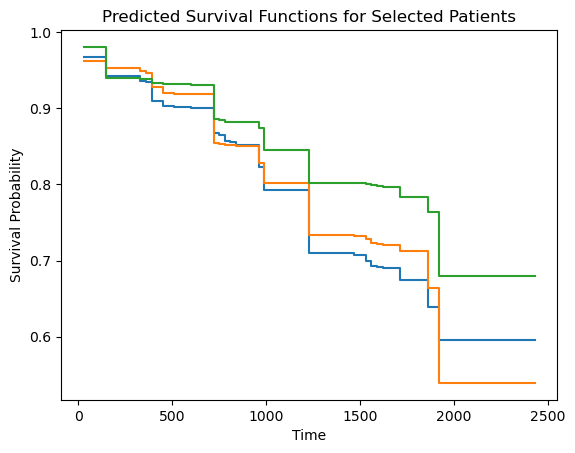

In [75]:
## Plot the survival function for the three first patients in the testing subset
X_test_sel=X_test.iloc[1:4,:]

# YOUR CODE GOES HERE

predicted_survival = estimator.predict_survival_function(X_test_sel)    
for surv_func in predicted_survival:
    plt.step(surv_func.x, surv_func.y, where="post")
    
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.title('Predicted Survival Functions for Selected Patients')  

What property do you observe, compared to the plot of the CPH above, in terms of the shape of the three lines?

Answer:

The Survival function is not continous as in the previous case. Here we can see that the survival function goes down in discrete steps as in before it was continous. 

In [76]:
len(df)

84

## TASK 17 (4 POINTS)
---
Please answer the questions below

In TASK 4, we split the dataset into two subsets for training (80%) and testing (20%). Considering the size of the dataset we use in this lab, do you think this split is a good choice？ What method or methods we could take into consideration when the dataset is too small for implementing this split?

Answer:

In this case, I don’t think it’s a good idea because our dataset is limited. We only have 84 data points, and allocating 20% of them to a test set is quite costly. A better approach would be to use cross-validation to tune the model’s parameters. After selecting the best-performing model through training and validation, we can then perform one final training pass on the entire dataset to ensure the model has access to as much data as possible before deployment

# TASK 18 (15 POINTS)
---
Using the decision tree code that you created in Lab 1 as a base, create your own Survival Tree algorithm, using the splitting criterion of your choice (you can use Logrank statistic or likelihood ratio statistic, as indicated in the course's slides). The algorithm should include the same hyper-parameters from Lab 1 and also min_obs_leaf, which indicates the minimum number of observations that a leaf should have. Use the training subset to train a survival tree and represent the survival functions on the three first patients from the testing subset.

In [86]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from pandas.api.types import is_numeric_dtype
import matplotlib.pyplot as plt

class SurvivalNode:
    """A decision node that splits data based on a predictor and threshold."""
    def __init__(self, predictor, threshold, left, right):
        self.predictor = predictor
        self.threshold = threshold
        self.left = left
        self.right = right

class SurvivalLeaf:
    """A leaf node that stores the Kaplan Meier survival curve."""
    def __init__(self, df):
        self.kmf = KaplanMeierFitter()
        self.kmf.fit(df['time'], event_observed=df['death'], label='Leaf Survival')
        self.n_samples = len(df)

def get_best_split_survival(df, min_obs_leaf):
    """
    Finds the best split by maximizing the Log-rank test statistic.
    Ensures that both child nodes have at least min_obs_leaf samples.
    """
    best_logrank = -1
    best_predictor = None
    best_threshold = None
    
    features = [c for c in df.columns if c not in ['time', 'death']]
    
    for predictor in features:
        # Get unique values for potential thresholds
        thresholds = df[predictor].unique()
        
        # Skip if too many unique values (optimization) or too few
        if len(thresholds) < 2:
            continue
            
        for threshold in thresholds:
            # Create the split mask
            if is_numeric_dtype(df[predictor]):
                mask = df[predictor] <= threshold
            else:
                mask = df[predictor] == threshold
                
            df_left = df[mask]
            df_right = df[~mask]
            
            # Constraint: Check min_obs_leaf
            if len(df_left) < min_obs_leaf or len(df_right) < min_obs_leaf:
                continue
                
            # Calculate Log-rank statistic (higher is better)
            try:
                results = logrank_test(
                    df_left['time'], df_right['time'],
                    event_observed_A=df_left['death'], event_observed_B=df_right['death']
                )
                score = results.test_statistic
            except:
                score = 0
            
            if score > best_logrank:
                best_logrank = score
                best_predictor = predictor
                best_threshold = threshold
                
    return best_predictor, best_threshold, best_logrank

# define the Main Training Function
def train_survival_tree(df, min_obs_leaf=5, max_depth=5, current_depth=0):
    """
    Recursively builds a Survival Tree.
    """
    if (current_depth >= max_depth) or (len(df) < 2 * min_obs_leaf):
        return SurvivalLeaf(df)
    
    # Find best split
    predictor, threshold, score = get_best_split_survival(df, min_obs_leaf)
    
    # If no valid split found (score is still -1 or 0), return leaf
    if predictor is None or score <= 0:
        return SurvivalLeaf(df)
    
    # Perform the split
    if is_numeric_dtype(df[predictor]):
        mask = df[predictor] <= threshold
    else:
        mask = df[predictor] == threshold
        
    left_node = train_survival_tree(df[mask], min_obs_leaf, max_depth, current_depth + 1)
    right_node = train_survival_tree(df[~mask], min_obs_leaf, max_depth, current_depth + 1)
    
    return SurvivalNode(predictor, threshold, left_node, right_node)

#  define Prediction Function
def predict_survival_tree(node, row):
    """
    Traverses the tree for a single patient row and returns the leaf's KM fitter.
    """
    if isinstance(node, SurvivalLeaf):
        return node.kmf
    
    # Traverse decision nodes
    if is_numeric_dtype(row[node.predictor]): # Numeric split
        if row[node.predictor] <= node.threshold:
            return predict_survival_tree(node.left, row)
        else:
            return predict_survival_tree(node.right, row)
    else: # Categorical split
        if row[node.predictor] == node.threshold:
            return predict_survival_tree(node.left, row)
        else:
            return predict_survival_tree(node.right, row)


Training Survival Tree...
Training Complete!

Plotting Survival Curves for first 2 Test Patients:


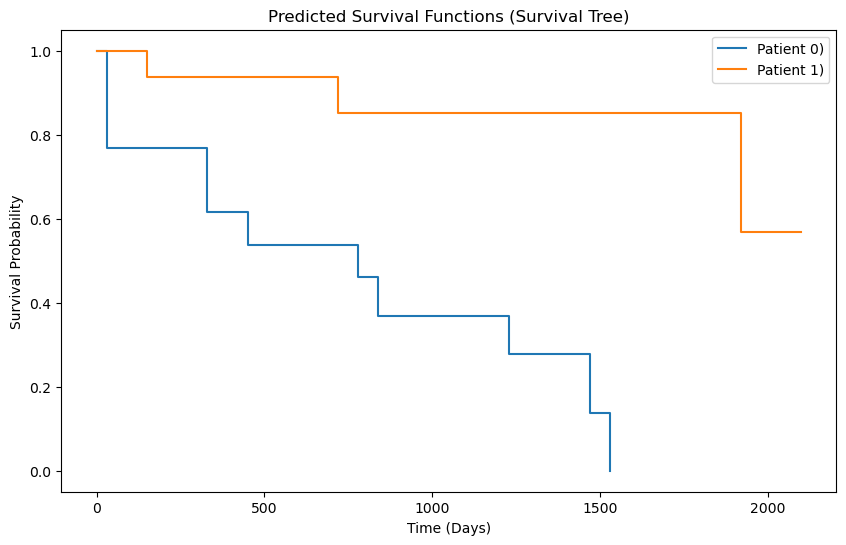

In [104]:

print("Training Survival Tree...")
my_survival_tree = train_survival_tree(dfTrain, min_obs_leaf=10, max_depth=4)
print("Training Complete!")

print("\nPlotting Survival Curves for first 2 Test Patients:")
plt.figure(figsize=(10, 6))

for i in range(2):
    patient_row = dfTest.iloc[i]
    
    # Get the survival curve (KM fitter) from the tree
    predicted_kmf = predict_survival_tree(my_survival_tree, patient_row)
    
    # Plot it
    predicted_kmf.plot_survival_function(ci_show=False, label=f"Patient {i})")

plt.title("Predicted Survival Functions (Survival Tree)")
plt.xlabel("Time (Days)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

# TASK 19 (10 POINTS) (Bonus)
---
Reimplement the survival tree algorithm from Task 18 using a different method for the splitting criteria.

In [92]:
# YOUR CODE GOES HERE


from lifelines.utils import concordance_index
import numpy as np

def get_risk_score(kmf):
    # Simply sum the survival probabilities to get restricted mean survival time
    # This is effectively the area under the curve
    mean_survival_time = np.sum(kmf.survival_function_.values)
    return mean_survival_time

predicted_risks = []

for i in range(len(dfTest)):
    patient = dfTest.iloc[i]
    
    # traverse the tree to get the leaf's KM curve
    kmf_prediction = predict_survival_tree(my_survival_tree, patient)
    
    # Convert curve to a risk score
    risk = get_risk_score(kmf_prediction)
    predicted_risks.append(risk)

# calculate concordance index
c_index_tree = concordance_index(dfTest['time'], predicted_risks, dfTest['death'])

print(f"Survival Tree C-Index on Test Set: {c_index_tree:.4f}")

Survival Tree C-Index on Test Set: 0.6164


What is a benefit of your new splitting criteria compared to the one you previously used?

Answer:


What is a drawback of your new splitting criteria compared to the one you previously used?

Answer:

## TASK 20
---
Run the following cell to finish the lab.

In [101]:
from IPython.display import IFrame

IFrame(
    src="https://www.youtube.com/embed/WWjPol5FLF8",
    width=560,
    height=315
)


Paste your colab link here:

NOTE: Lab was done on vscode

**You are ready to submit in Gradescope!**

Please suffix your colab file with _\<JHED ID\> (It's the part before the @ symbol in your email)

e.g. Lab1_Decision_trees_myjhedID

4 easy steps to submit your lab:

1.   Click on "Share" option on top right - Click on "copy link" option. Make sure your permission is set to "Anyone on the internet with this link can view". And paste it in the cell above.
2.   Go to "File" - "Download .ipynb" and "Download .py".
3.   Export the notebook to a PDF file with all the outputs.
3.   Upload the three files (.pdf, .ipynb, .py) to Gradescope.

That's it!